# Task 4 — Predicting Insurance Claim Amounts (Medical Charges)

## Objective
Predict medical insurance charges (`charges`) using Linear Regression.

## Important
If the local CSV does not contain the required columns (e.g., `charges`),
this notebook will automatically download the correct public dataset and continue.

## Output
- EDA plots: Age/BMI/Smoker vs Charges
- Model: Linear Regression (Pipeline + ColumnTransformer)
- Metrics: MAE, RMSE (and R²)

In [15]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import urllib.request
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# --------------------
# Repo paths
# --------------------
def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start] + list(start.parents):
        if (p / ".git").exists() or (p / "data").exists():
            return p
    return start

ROOT = find_repo_root()
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs" / "task4_figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", ROOT)
print("Data dir :", DATA_DIR)
print("Out dir  :", OUT_DIR)

# --------------------
# Helpers
# --------------------
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.astype(str).str.strip().str.lower()
        .str.replace(r"[ \-./]", "_", regex=True)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
    )
    return df

def save_fig(filename: str) -> None:
    try:
        p = OUT_DIR / filename
        plt.tight_layout()
        plt.savefig(p, dpi=150, bbox_inches="tight")
        print("Saved:", p)
    except Exception as e:
        print("Note: could not save figure:", e)

def read_csv_safely(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep=None, engine="python")

Repo root: f:\coding\DevelopersHub-DS-Internship-Tasks
Data dir : f:\coding\DevelopersHub-DS-Internship-Tasks\data
Out dir  : f:\coding\DevelopersHub-DS-Internship-Tasks\outputs\task4_figures


In [18]:
# Try to find an "insurance" CSV in data/
csvs = sorted(DATA_DIR.glob("*.csv"))
print("CSV files in data/:", [f.name for f in csvs])

local_path = None
for f in csvs:
    if "insurance" in f.name.lower():
        local_path = f
        break

# fallback: if only one CSV exists, use it
if local_path is None and len(csvs) == 1:
    local_path = csvs[0]

df_local = None
if local_path is not None:
    df_local = normalize_columns(read_csv_safely(local_path))
    print("\nLoaded local file:", local_path.name)
    print("Local columns:", df_local.columns.tolist())
    display(df_local.head())
else:
    print("\nNo local CSV found in data/.")

CSV files in data/: ['bank_marketing.csv', 'Churn_Modelling.csv', 'insurance_medical_cost.csv', 'Iris.csv', 'loan-prediction.csv']

Loaded local file: insurance_medical_cost.csv
Local columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
# Task 4 requires these columns (minimum)
REQUIRED_FOR_TASK4 = {"age", "bmi", "smoker", "charges"}

def download_medical_cost_dataset(dest: Path) -> Path:
    url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
    print("Downloading correct dataset for Task 4 from:")
    print(url)
    urllib.request.urlretrieve(url, dest)
    print("Downloaded to:", dest)
    return dest

use_df = None
source = None

if df_local is not None:
    local_cols = set(df_local.columns)
    if REQUIRED_FOR_TASK4.issubset(local_cols):
        use_df = df_local
        source = f"local ({local_path.name})"
    else:
        print("\nYour local dataset does NOT match Task 4 requirements.")
        print("Task 4 needs columns:", sorted(REQUIRED_FOR_TASK4))
        print("But your file has   :", sorted(local_cols))
        print("Auto-fix: downloading the correct Medical Cost dataset...")

# If local mismatch or missing, download correct dataset
if use_df is None:
    dest = DATA_DIR / "insurance_medical_cost.csv"
    download_medical_cost_dataset(dest)
    use_df = normalize_columns(read_csv_safely(dest))
    source = f"downloaded ({dest.name})"

print("\nDataset selected:", source)
print("Shape:", use_df.shape)
print("Columns:", use_df.columns.tolist())
display(use_df.head())


Dataset selected: local (insurance_medical_cost.csv)
Shape: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## EDA (Required)
We will visualize how:
- age affects charges
- bmi affects charges
- smoker affects charges

Saved: f:\coding\DevelopersHub-DS-Internship-Tasks\outputs\task4_figures\eda_age_vs_charges.png


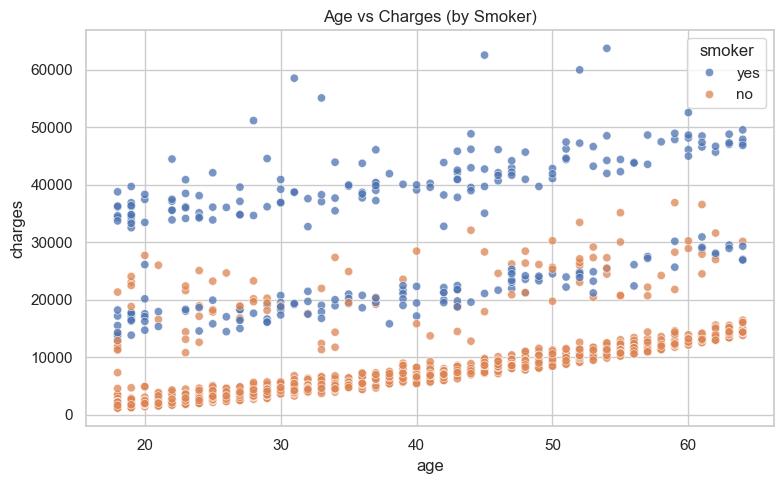

Saved: f:\coding\DevelopersHub-DS-Internship-Tasks\outputs\task4_figures\eda_bmi_vs_charges.png


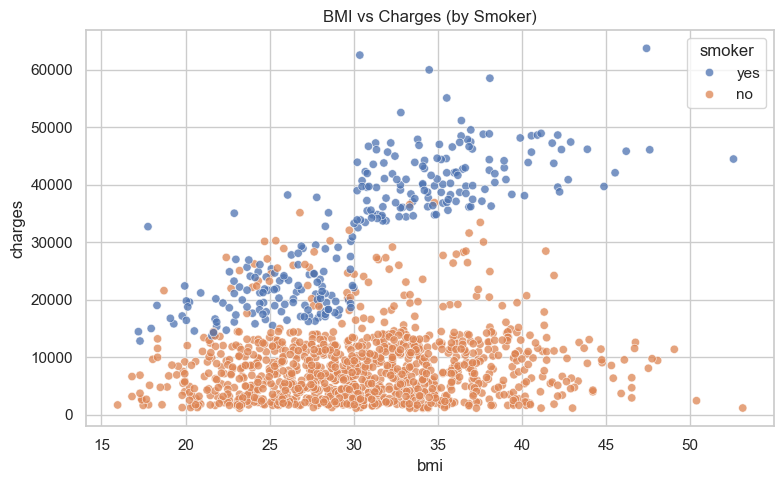

Saved: f:\coding\DevelopersHub-DS-Internship-Tasks\outputs\task4_figures\eda_charges_by_smoker.png


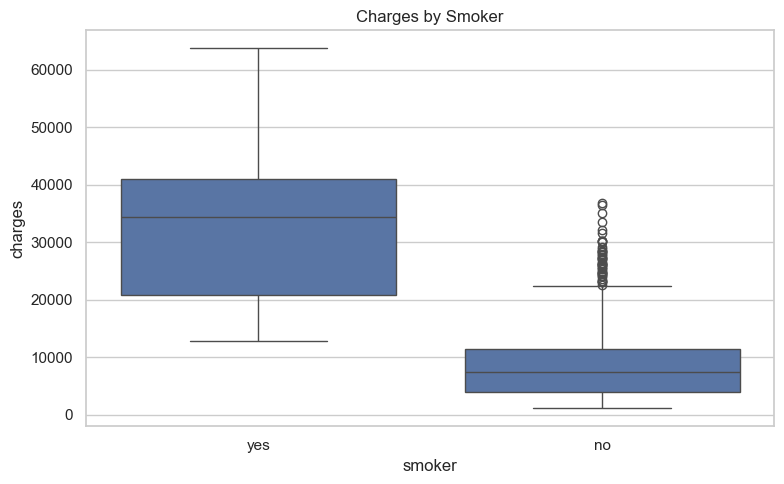

In [20]:
df = use_df  # standard name

# Age vs charges (colored by smoker)
ax = sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.75)
ax.set_title("Age vs Charges (by Smoker)")
save_fig("eda_age_vs_charges.png")
plt.show()

# BMI vs charges (colored by smoker)
ax = sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.75)
ax.set_title("BMI vs Charges (by Smoker)")
save_fig("eda_bmi_vs_charges.png")
plt.show()

# Smoker vs charges (boxplot)
ax = sns.boxplot(data=df, x="smoker", y="charges")
ax.set_title("Charges by Smoker")
save_fig("eda_charges_by_smoker.png")
plt.show()

In [21]:
TARGET = "charges"

X = df.drop(columns=[TARGET])
y = df[TARGET]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("linreg", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
print("Model trained successfully.")
print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

Model trained successfully.
Numeric cols: ['age', 'bmi', 'children']
Categorical cols: ['sex', 'smoker', 'region']


In [22]:
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred, squared=False)
r2 = r2_score(y_test, pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2  :", round(r2, 4))

MAE : 4181.19
RMSE: 5796.28
R2  : 0.7836


Saved: f:\coding\DevelopersHub-DS-Internship-Tasks\outputs\task4_figures\residuals_vs_predicted.png


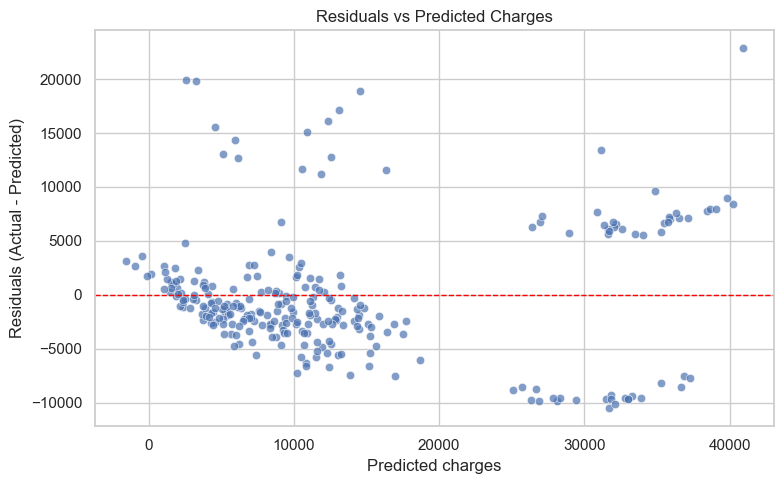

Saved: f:\coding\DevelopersHub-DS-Internship-Tasks\outputs\task4_figures\residual_distribution.png


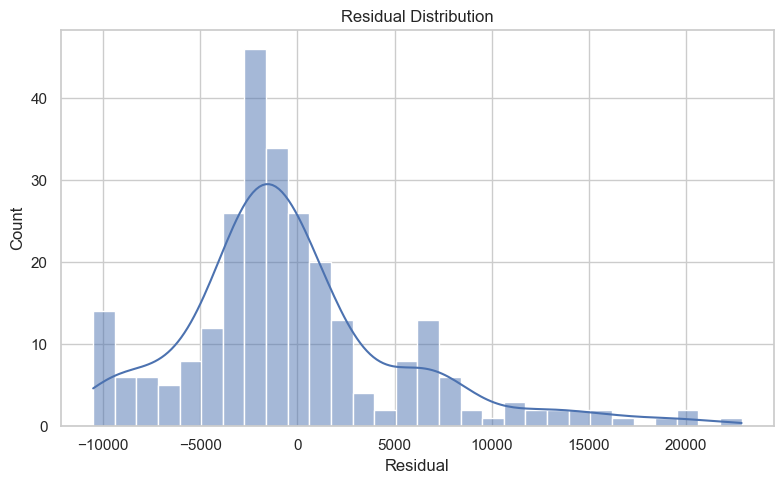

In [23]:
residuals = y_test - pred

ax = sns.scatterplot(x=pred, y=residuals, alpha=0.7)
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Residuals vs Predicted Charges")
ax.set_xlabel("Predicted charges")
ax.set_ylabel("Residuals (Actual - Predicted)")
save_fig("residuals_vs_predicted.png")
plt.show()

ax = sns.histplot(residuals, bins=30, kde=True)
ax.set_title("Residual Distribution")
ax.set_xlabel("Residual")
save_fig("residual_distribution.png")
plt.show()

## Conclusion
- Linear Regression baseline was trained using a clean preprocessing pipeline.
- MAE and RMSE quantify average and typical prediction error.
- EDA shows smoker status has a strong impact on charges, and charges also increase with age and BMI.
- Next improvements: try non-linear models (RandomForestRegressor / GradientBoosting) and log-transform charges.